In [92]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
import logging
import multiprocessing
import os
import pickle

logging.getLogger("pint").setLevel(logging.ERROR)

if os.environ.get("SLURM_CPUS_PER_TASK"):
    cores = int(os.environ.get("SLURM_CPUS_PER_TASK", 1))
else:
    cores = multiprocessing.cpu_count()
print(f"Number of cores: {cores}")

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count={}".format(cores)

from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table
from gpjax.kernels import RBF, Linear, Matern12, Periodic
from jax import jit
from jaxoplanet import orbits
from jaxoplanet.light_curves import LimbDarkLightCurve
from jaxopt import ScipyMinimize
from tensorflow_probability.substrates.jax.distributions import Normal
from tqdm import tqdm
from joblib import Parallel, delayed

from gallifrey.gps import (
    KernelSearch,
    get_trainables,
    kernel_summary,
    set_obs_stddev,
    predictive_distribution,
    whitened_residuals,
)
from gallifrey.inference import log_likelihood_function
from gallifrey.inference.mcmc import create_initial_positions, nuts_warmup, run_mcmc
from gallifrey.util import (
    dict_to_jnp,
    plot_allan_deviation,
    plot_masks,
    plot_prediction,
    plot_residuals,
)

Number of cores: 8


In [94]:
rng_key = jax.random.PRNGKey(42)

plt.style.use("../figures/gpjax.mplstyle")

mode = "save"

## LOAD DATA

In [95]:
model_name = "wasp94Ab_gpmodel"

df = Table.read("../data/external/WASP_94Ab.fit").to_pandas()

# time (adjust for simplicity)
t = df["Time"].to_numpy()
t_min = np.amin(t)
t -= t_min

# white lightcurve
white_lc = df["FluxWL"].to_numpy().T
white_lc_err = df["e_FluxWL"].to_numpy().T

# spectroscopic light curves
y = df.iloc[:, 1:-2:2].to_numpy().T
yerr = df.iloc[:, 2:-1:2].to_numpy().T

# mask out transit
mask = np.ones_like(t, dtype=bool)
mask[100:324] = False

# reference parameter from arXiv:2201.02212, last entry is white lc
reference = pd.read_csv("../data/external/WASP_94Ab_reference.csv").set_index(
    df.columns[1::2]
)

planet_period = 0.9501907


num_datasets = len(y)

## KERNEL SEARCH FOR WHITE LC

In [96]:
kernel_library = [
    Linear(),
    RBF(),
    Matern12(),
    Periodic(),
]

In [97]:
if mode == "load":
    with open(
        f"../data/processed/observational_data/gp_models/{model_name}", "rb"
    ) as file:
        model = pickle.load(file)

else:
    tree = KernelSearch(
        kernel_library,
        X=jnp.array(t[mask]),
        y=jnp.array(white_lc[mask]),
        obs_stddev=jnp.amax(white_lc_err[mask]),
        fit_obs_stddev=True,
        verbosity=1,
        num_threads=cores,
    )

    model = tree.search(
        depth=10,
        n_leafs=5,
        patience=2,
    ).posterior

    if mode == "save":
        with open(
            f"../data/processed/observational_data/gp_models/{model_name}", "wb"
        ) as file:
            pickle.dump(model, file)

summary = kernel_summary(model, to_latex=False)

Kernel Summary

Number of Parameter: 4
Kernel Structure: Periodic + Linear • Linear • Linear • Linear
  with obs_stddev = 1.81217e-04 (Trainable : False)

Kernel               Property             Value                Trainable 
--------------------------------------------------------------------------------
Periodic            lengthscale          2.17445e+03          True      

                    variance             1.00140e+00          True      

                    period               3.97816e+03          True      
--------------------------------------------------------------------------------
Linear              variance             7.04769e-03          True      
--------------------------------------------------------------------------------
Linear              variance             1.00000e+00          False     
--------------------------------------------------------------------------------
Linear              variance             1.00000e+00          False     
-------

## DEFINE TRANSIT MODEL

In [98]:
def transit_model(
    t,
    transit_parameter,
    fixed_parameter,
):
    get_value = (
        lambda key: fixed_parameter[key]
        if key in fixed_parameter
        else transit_parameter[key]
    )

    central = orbits.keplerian.Central(
        mass=get_value("central_mass"),
        radius=get_value("central_radius"),
    )

    orbit = orbits.keplerian.Body(
        central=central,
        period=get_value("period"),
        radius=get_value("planet_radius")
        * central.radius,  # radius in units of stellar radius
        inclination=get_value("inclination"),
        time_transit=get_value("time_transit"),
    )

    u1 = get_value("u1")
    u2 = get_value("u2")
    return LimbDarkLightCurve([u1, u2]).light_curve(orbit, t=t)

## FIT TRANSIT PARAMETER FOR WHITE LC

In [99]:
white_lc_log_likelihood = log_likelihood_function(
    model,
    jit(
        partial(
            transit_model,
            fixed_parameter={"period": planet_period, "u2": reference["u2"]["FluxWL"]},
        )
    ),  # partial returns fixed_parameter fixed
    t,
    white_lc,
    mask,
    fix_gp=False,
    compile=True,
    negative=True,
)

x0 = {
    "gp_parameter": get_trainables(model, unconstrain=True),
    "lc_parameter": {
        "planet_radius": 0.11,
        "u1": 0.53,
        "central_mass": 1.45,
        "central_radius": 1.653,
        "inclination": jnp.deg2rad(89.3),
        "time_transit": 0.18,
    },
}
white_lc_solve = ScipyMinimize(
    fun=white_lc_log_likelihood,
    method="l-bfgs-b",
).run(x0)
white_lc_parameter = white_lc_solve.params["lc_parameter"]

In [100]:
fixed_parameter = {
    param: white_lc_parameter[param]
    for param in (
        "central_mass",
        "central_radius",
        "inclination",
        "time_transit",
    )
}
fixed_parameter["period"] = planet_period

## DEFINE LIKELIHOOD, PRIOR, POSTERIOR

In [101]:
def get_logprob(
    gp_model,
    y,
    yerr,
    u1,
    u2,
    initial_position=None,
    fix_gp=False,
):
    # reset stddev estimate to observation
    gp_model = gp_model.likelihood.replace(obs_stddev=yerr) * gp_model.prior

    if initial_position is None:
        initial_position = {
            "gp_parameter": get_trainables(gp_model, unconstrain=True),
            "lc_parameter": {"planet_radius": 0.10, "u1": u1},
        }

    # define transit light curve model
    fixed_parameter["u2"] = u2
    lc_model = jit(partial(transit_model, fixed_parameter=fixed_parameter))

    # get log likelihood function
    log_likelihood = log_likelihood_function(
        gp_model,
        lc_model,
        t,
        y,
        mask,
        fix_gp=fix_gp,
        compile=True,
    )

    # define priors
    param_priors = {
        "gp_parameter": Normal(
            loc=initial_position["gp_parameter"],
            scale=0.1 * jnp.abs(initial_position["gp_parameter"]),
        ),
        "lc_parameter": Normal(
            loc=dict_to_jnp(initial_position["lc_parameter"]),
            scale=[0.2, 0.05],
        ),
    }

    @jit
    def log_priors(params):
        gp_log_priors = param_priors["gp_parameter"].log_prob(params["gp_parameter"])
        lc_log_priors = param_priors["lc_parameter"].log_prob(
            dict_to_jnp(params["lc_parameter"])
        )
        return jnp.sum(gp_log_priors) + jnp.sum(lc_log_priors)

    # put it all together to full posterior probability function
    @jit
    def log_probability(params):
        return log_likelihood(params) + log_priors(params)

    return log_probability, initial_position

## PERFORM FITS

In [102]:
parameter_solutions = []
for i in tqdm(range(num_datasets)):
    log_probability, initial_position = get_logprob(
        model,
        y[i],
        jnp.amax(yerr[i]),
        reference["u1_linear"].iloc[i],
        reference["u2"].iloc[i],
    )

    solve = ScipyMinimize(
        fun=jit(lambda par: -log_probability(par)), method="l-bfgs-b"
    ).run(initial_position)
    parameter_solutions.append(solve.params)

100%|██████████| 19/19 [01:50<00:00,  5.83s/it]


## RUN MCMC

In [12]:
# Adapted from BlackJax's introduction notebook.
num_adapt = 150
num_samples = 80
num_chains = cores

fix_gp = False

In [13]:
rng_key, warmup_key = jax.random.split(rng_key, 2)

if mode != "load":
    # run nuts adaption on white lc
    log_probability, initial_position = get_logprob(
        model,
        white_lc,
        white_lc_err,
        reference["u1_linear"]["FluxWL"],
        reference["u2"]["FluxWL"],
        fix_gp=fix_gp,
    )

    state, nuts_parameters = nuts_warmup(
        warmup_key,
        log_probability,
        initial_position,
        num_steps=num_adapt,
    )

In [14]:
chains = {"gp_parameter": [], "lc_parameter": []}

if mode == "load":
    chains = np.load(
        f"../data/processed/observational_data/mcmc_chains/{model_name}_parameter.npz"
    )

else:
    for i in tqdm(range(num_datasets)):
        log_probability, initial_position = get_logprob(
            model,
            y[i],
            jnp.amax(yerr[i]),
            reference["u1_linear"].iloc[i],
            reference["u2"].iloc[i],
            initial_position=parameter_solutions[i],
            fix_gp=fix_gp,
        )

        # define initial positions and add scatter
        rng_key, gp_scatter_key = jax.random.split(rng_key, 2)

        initial_positions = {}
        initial_positions["gp_parameter"] = create_initial_positions(
            initial_position["gp_parameter"],
            num=num_chains,
            sigma=0.05,
            key=gp_scatter_key,
        )
        initial_positions["lc_parameter"] = {}
        for name, value in initial_position["lc_parameter"].items():
            rng_key, scatter_key = jax.random.split(rng_key, 2)
            initial_positions["lc_parameter"][name] = create_initial_positions(
                value,
                num=num_chains,
                sigma=0.05,
                key=scatter_key,
            )

        # run mcmc
        rng_key, sample_key = jax.random.split(rng_key, 2)

        final_state, state_history, info_history = run_mcmc(
            sample_key,
            log_probability,
            nuts_parameters,
            initial_positions,
            num_steps=num_samples,
        )

        for par in ["gp_parameter", "lc_parameter"]:
            chain = dict_to_jnp(state_history.position[par])
            if par == "lc_parameter":
                chain = chain.transpose(
                    [1, 2, 0]
                )  # get array in same order as gp_parameter
            chains[par].append(chain)

    if mode == "save":
        np.savez(
            f"../data/processed/observational_data/mcmc_chains/{model_name}_parameter.npz",
            **chains,
        )

## ANALYSIS

### PLOT SPECTRUM

In [27]:
Rp_percentiles = np.percentile(
    np.array(chains["lc_parameter"]).reshape(num_datasets, -1, 2),
    [50, 16, 84],
    axis=1,
)[:, :, 0]
errorbars = np.array(
    [Rp_percentiles[0] - Rp_percentiles[1], Rp_percentiles[2] - Rp_percentiles[0]]
)

In [54]:
normalise = lambda array, offset: array - np.mean(array) + offset
reference_depth = 0.10544  # white LC transit depth from Ahrer+2022 using GP detrending

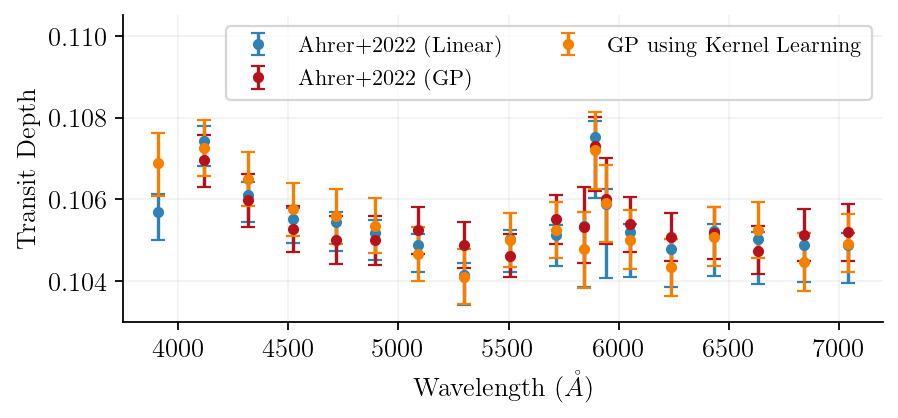

In [80]:
fig, ax = plt.subplots()

ax.errorbar(
    reference["wavelength"].iloc[:-1],
    normalise(reference["Rp_linear"][:-1], reference_depth),
    yerr=reference[["e_Rp_linear_lower", "e_Rp_linear_upper"]][:-1].T,
    fmt=".",
    capsize=3,
    label="Ahrer+2022 (Linear)",
)
ax.errorbar(
    reference["wavelength"].iloc[:-1],
    normalise(reference["Rp_gp"][:-1], reference_depth),
    yerr=reference[["e_Rp_gp_lower", "e_Rp_gp_upper"]][:-1].T,
    fmt=".",
    capsize=3,
    label="Ahrer+2022 (GP)",
)
ax.errorbar(
    reference["wavelength"].iloc[:-1],
    normalise(Rp_percentiles[0], reference_depth),
    yerr=errorbars,
    fmt=".",
    capsize=3,
    label="GP using Kernel Learning",
)


ax.set_ylim(0.103, 0.1105)
ax.legend(ncols=2)
ax.set_xlabel(r"Wavelength ($\mathring{A}$)")
ax.set_ylabel("Transit Depth")
fig.savefig("../figures/005_WASP94Ab/spectrum.pdf")

### LIGHT CURVES

In [81]:
rng_key, sample_key = jax.random.split(rng_key)

# get indices for random sample from mcmc chain
num_parameter_samples = 100
parameter_sample_indices = jax.random.choice(
    sample_key,
    np.array(chains["lc_parameter"])
    .reshape(num_datasets, -1, 2)
    .shape[1],  # flatten chains
    shape=(num_parameter_samples,),
)

In [87]:
samples_with_transit = {}
samples_without_transit = {}
residuals = {}

for i in tqdm(range(num_datasets)):
    jax.clear_caches()

    # flatten chains
    lc_parameter = chains["lc_parameter"][i].reshape(
        -1, chains["lc_parameter"][i].shape[-1]
    )
    gp_parameter = chains["gp_parameter"][i].reshape(
        -1, chains["gp_parameter"][i].shape[-1]
    )

    fixed_parameter["u2"] = reference["u2"].iloc[i]
    transit = jit(partial(transit_model, fixed_parameter=fixed_parameter))

    # update model uncertainty
    model = set_obs_stddev(model, jnp.amax(yerr[i][mask]))

    def get_sample(idx, rng_key, num_samples=10):
        dist = predictive_distribution(
            model,
            t,
            X=jnp.array(t[mask]),
            y=jnp.array(y[i][mask]),
            transit_model=transit,
            transit_parameter={
                parameter: lc_parameter[idx][j]
                for j, parameter in enumerate(["planet_radius", "u1"])
            },
            gp_parameter=gp_parameter[idx],
        )
        sample_with_transit = dist.sample(sample_shape=num_samples, seed=rng_key)
        sample_without_transit = sample_with_transit - transit(
            t,
            {
                parameter: lc_parameter[idx][i]
                for i, parameter in enumerate(["planet_radius", "u1"])
            },
        )
        residuals = whitened_residuals(y[i], dist)
        return sample_with_transit, sample_without_transit, residuals

    rng_key, *sample_keys = jax.random.split(rng_key, num_parameter_samples + 1)

    samples = Parallel(n_jobs=cores)(
        delayed(get_sample)(idx, key)
        for idx, key in zip(
            parameter_sample_indices,
            sample_keys,
        )
    )

    samples_with_transit[i] = jnp.array(
        [samples[i][0] for i in range(num_parameter_samples)]
    ).reshape(-1, len(y[i]))
    samples_without_transit[i] = jnp.array(
        [samples[i][1] for i in range(num_parameter_samples)]
    ).reshape(-1, len(y[i]))
    residuals[i] = jnp.array([samples[i][2] for i in range(num_parameter_samples)])

residuals_std = [
    (jnp.array(residuals[i]).reshape(-1, len(y[i])) ** 2).mean()
    for i in residuals.keys()
]

100%|██████████| 19/19 [14:37<00:00, 46.17s/it]


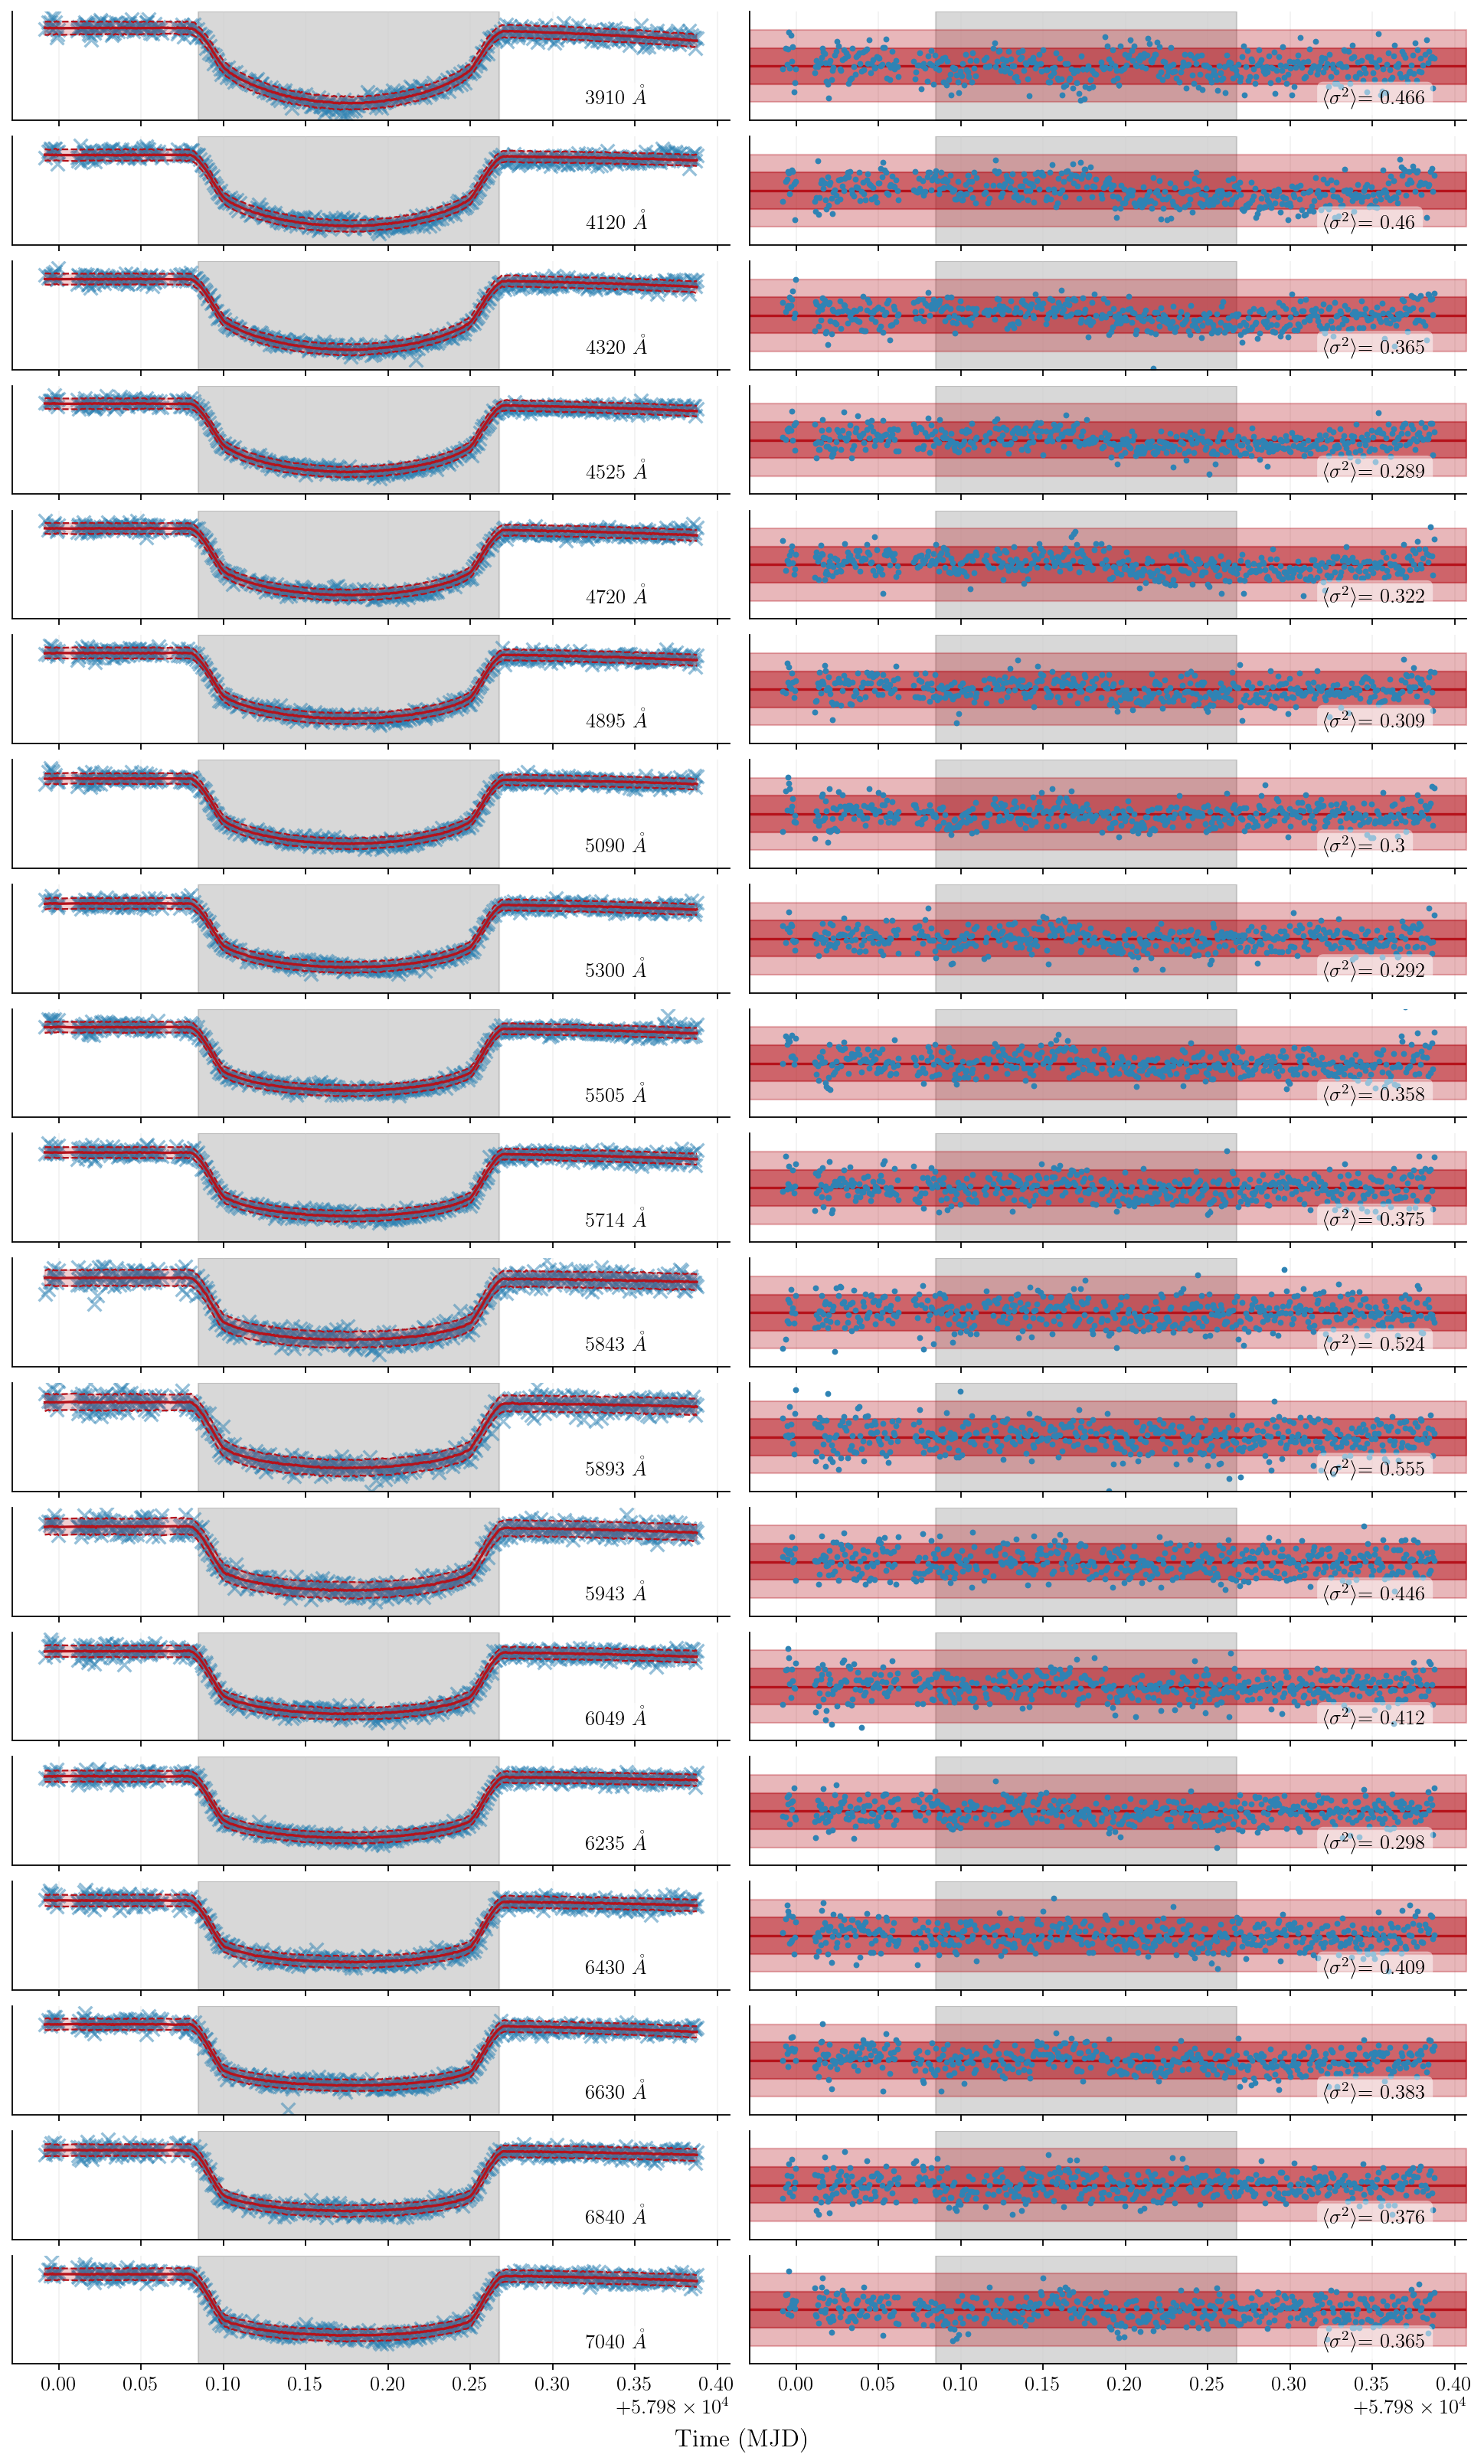

In [90]:
fig, ax = plt.subplots(
    num_datasets,
    2,
    figsize=(12, 20),
    constrained_layout=False,
    sharex="col",
    sharey="col",
)
fig.subplots_adjust(hspace=0, wspace=0.01)

for i in range(num_datasets):
    t_ = t + t_min
    ax[i, 0].scatter(
        t_,
        y[i],
        alpha=0.5,
    )
    plot_prediction(
        ax[i, 0],
        t_,
        jnp.array(samples_with_transit[i]),
        errorbar=68,
    )
    # plot_prediction(
    #     ax[i, 0],
    #     t_[~mask],
    #     jnp.array(samples_without_transit[i])[:, ~mask],
    #     kws_mean={"color": "grey", "alpha": 0.7},
    # )
    plot_residuals(
        ax[i, 1],
        t_,
        jnp.array(residuals[i]),
        credible_region=68,
        kws_residuals={"markersize": 5},
    )
    ax[i, 1].set_ylim(-3, 3)
    ax[i, 1].yaxis.set_label_position("right")
    ax[i, 1].yaxis.tick_right()
    for j in [0, 1]:
        plot_masks(ax[i, j], t_, jnp.array(mask))
        ax[i, j].set_yticks([])

    for j in range(2):
        if j == 0:
            text_str = str(reference["wavelength"].iloc[i]) + r" $\mathring{A}$"
        else:
            text_str = rf"$\langle \sigma^2 \rangle$= {residuals_std[i]:.3}"

        ax[i, j].text(
            0.8,
            0.15,
            text_str,
            transform=ax[i, j].transAxes,
            bbox={
                "boxstyle": "round",
                "facecolor": "white",
                "alpha": 0.5,
                "edgecolor": "none",
            },
        )

fig.supxlabel("Time (MJD)")
fig.savefig("../figures/005_WASP94Ab/light_curves_and_residuals.pdf")